In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv("data/Banking_Cleaned.csv")

In [3]:
X = df.drop(columns=["F3924"])
y = df["F3924"]

In [4]:
X["F3888"].value_counts()

F3888
9-19-2025     24
9-17-2025     20
10-13-2025    18
9-23-2025     16
11-7-2025     16
              ..
3-19-2009      1
9-20-1989      1
10-28-2011     1
4-4-2017       1
9-24-2007      1
Name: count, Length: 4292, dtype: int64

### Feature Engineering

In [ ]:
X["F3888"] = pd.to_datetime(X["F3888"])

X["Account_Year"] = X["F3888"].dt.year
X["Account_Month"] = X["F3888"].dt.month

# Optional
X["Account_Age_Days"] = (pd.Timestamp.today() - X["F3888"]).dt.days

X.drop(columns=["F3888"], inplace=True)

PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X["Account_Year"] = X["F3888"].dt.year
PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X["Account_Month"] = X["F3888"].dt.month
PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X["Account_Age_Days"] = (pd.Timestamp.today() - X["F3888"]).dt.days

### Encoding


In [6]:
X = pd.get_dummies(
    X,
    columns=["F2230","F3886","F3889","F3890","F3891","F3892","F3893"],
    drop_first=True,
    dtype=int
)

In [7]:
X.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F3891_housewife,F3891_others,F3891_retired,F3891_salaried,F3891_selfemployed,F3891_student,F3892_M,F3892_O,F3892_Unknown,F3893_RETAIL
0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.33,0.5,0.47,...,0,0,0,0,1,0,1,0,0,1
1,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.33,0.5,0.47,...,0,0,0,0,1,0,1,0,0,1
2,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.33,0.5,0.47,...,0,0,0,0,0,1,1,0,0,1
3,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.33,0.5,0.47,...,0,0,0,0,1,0,1,0,0,1
4,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.33,0.5,0.47,...,0,0,0,0,0,1,1,0,0,1


In [8]:
y.value_counts()

F3924
0    9001
1      81
Name: count, dtype: int64

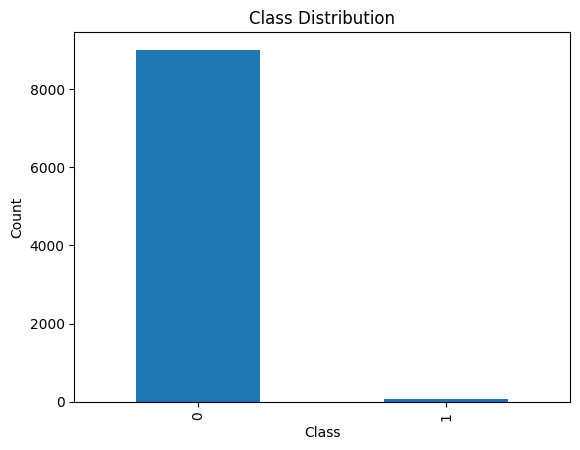

In [9]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [13]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy : 0.9977985690698954
Precision: 0.8
Recall   : 1.0
F1 Score : 0.8888888888888888

Confusion Matrix:
[[1797    4]
 [   0   16]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       0.80      1.00      0.89        16

    accuracy                           1.00      1817
   macro avg       0.90      1.00      0.94      1817
weighted avg       1.00      1.00      1.00      1817



In [15]:
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_prob_logistic))

ROC AUC: 0.9994447529150472


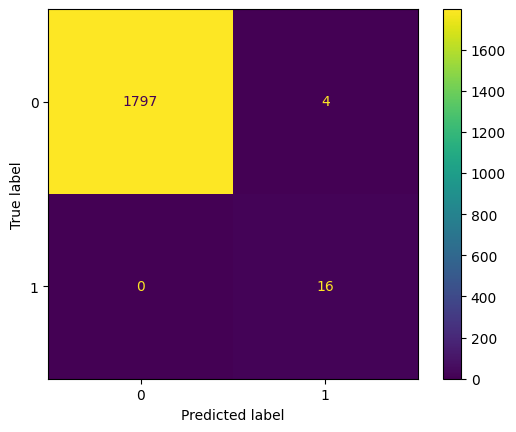

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logistic)
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [18]:
# Different class weights to try
class_weight = (
    ["balanced"] +
    [{0:1, 1:w} for w in [5, 10, 25, 50, 100]]
)

# Parameter Grid
params = [
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [100, 10, 1, 0.1, 0.01],
        'class_weight': class_weight
    },
    {
        'penalty': ['l2'],
        'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
        'C': [100, 10, 1, 0.1, 0.01],
        'class_weight': class_weight
    }
]

In [ ]:
# # Stratified K-Fold
# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )
# # Grid Search
# grid = GridSearchCV(
#     estimator=logistic_model,
#     param_grid=params,
#     scoring='f1',         
#     cv=cv,
#     n_jobs=-1,
#     verbose=2
# )

# # Train
# grid.fit(X_train_scaled, y_train)

# # Best Parameters
# print("Best Parameters:")
# print(grid.best_params_)

# print("\nBest CV Score:")
# print(grid.best_score_)

Fitting 5 folds for each of 210 candidates, totalling 1050 fits


KeyboardInterrupt: 

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# random_search = RandomizedSearchCV(
#     estimator=logistic_model,
#     param_distributions=params,
#     n_iter=10,          # Try only 10 random combinations
#     scoring='f1',
#     cv=cv,
#     n_jobs=-1,
#     random_state=42,
#     verbose=2
# )

# random_search.fit(X_train_scaled, y_train)

# print(random_search.best_params_)
# print(random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [23]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9977985690698954
Precision: 1.0
Recall   : 0.75
F1 Score : 0.8571428571428571
ROC AUC  : 0.9996876735147141

Confusion Matrix:
[[1801    0]
 [   4   12]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      0.75      0.86        16

    accuracy                           1.00      1817
   macro avg       1.00      0.88      0.93      1817
weighted avg       1.00      1.00      1.00      1817



In [25]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

          Feature  Importance
3712  F2230_Oct25    0.069543
3682        F3898    0.019427
3696        F3912    0.018982
3602        F3811    0.015898
1104        F1166    0.012705
1320        F1382    0.012554
1428        F1490    0.011671
3713  F2230_Sep25    0.011401
3596        F3805    0.011290
3597        F3806    0.010320
1535        F1597    0.009753
3592        F3801    0.009484
1859        F1921    0.009408
2399        F2487    0.008672
995         F1057    0.008248
1763        F1825    0.008025
241          F270    0.008004
3598        F3807    0.007995
3603        F3812    0.007858
1861        F1923    0.007729


In [26]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

y_pred_th0_30 = (y_prob >= 0.30).astype(int)

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_th0_30))
print("Precision:", precision_score(y_test, y_pred_th0_30))
print("Recall   :", recall_score(y_test, y_pred_th0_30))
print("F1 Score :", f1_score(y_test, y_pred_th0_30))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_th0_30))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_th0_30))

Accuracy : 0.9977985690698954
Precision: 0.9285714285714286
Recall   : 0.8125
F1 Score : 0.8666666666666667
ROC AUC  : 0.9996876735147141

Confusion Matrix:
[[1800    1]
 [   3   13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       0.93      0.81      0.87        16

    accuracy                           1.00      1817
   macro avg       0.96      0.91      0.93      1817
weighted avg       1.00      1.00      1.00      1817



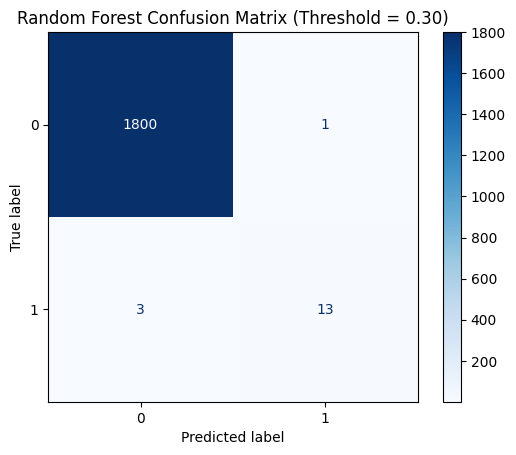

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_th0_30,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix (Threshold = 0.30)")
plt.show()

## XgBoost


In [29]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)


110.76923076923077


In [30]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Confusion Matrix:
[[1801    0]
 [   0   16]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      1.00      1.00        16

    accuracy                           1.00      1817
   macro avg       1.00      1.00      1.00      1817
weighted avg       1.00      1.00      1.00      1817



F2230_Oct25            1.0
F2                     0.0
F3                     0.0
F4                     0.0
F5                     0.0
F6                     0.0
F3886_HL               0.0
F3886_ML               0.0
F3886_MSME LA TDR      0.0
F3886_MSME Medium      0.0
F3886_MSME Micro       0.0
F3886_MSME Small       0.0
F3886_PL               0.0
F3886_Retail LA TDR    0.0
F3886_Retail Others    0.0
F3886_Savings          0.0
F3886_Staff Loans      0.0
F3886_Term Deposit     0.0
F3889_L14D             0.0
F3889_L180D            0.0
dtype: float32


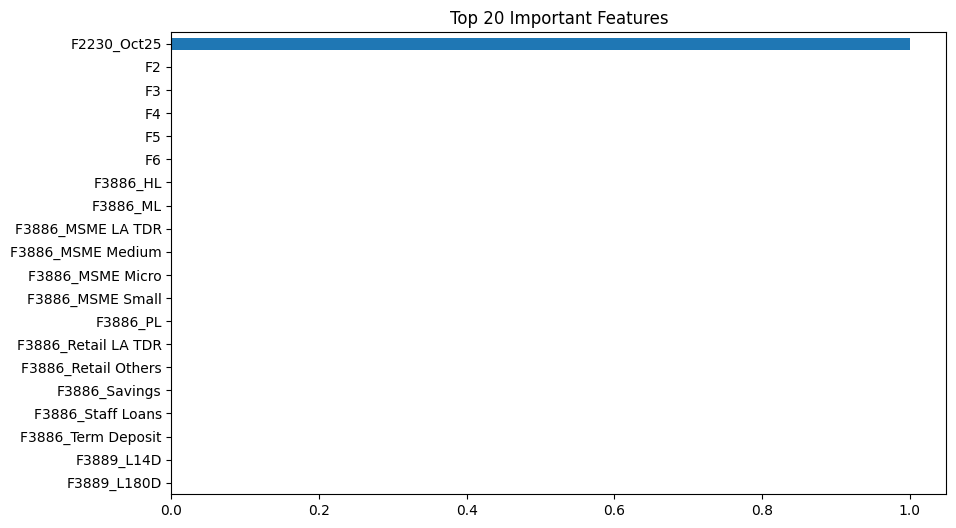

In [35]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)
print(importance.head(20))
plt.figure(figsize=(10,6))
importance.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

In [36]:
pd.crosstab(df["F2230"], df["F3924"])

F3924,0,1
F2230,,
Dec25,0,10
Nov25,0,23
Oct25,9001,0
Sep25,0,48


In [37]:
[col for col in X.columns if col.startswith("F2230")]

['F2230_Nov25', 'F2230_Oct25', 'F2230_Sep25']

In [38]:
X_drp = X.drop(columns=[
    'F2230_Oct25',
    'F2230_Sep25',
    'F2230_Nov25',
])

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_drp,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy : 0.9977985690698954
Precision: 0.8
Recall   : 1.0
F1 Score : 0.8888888888888888

Confusion Matrix:
[[1797    4]
 [   0   16]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       0.80      1.00      0.89        16

    accuracy                           1.00      1817
   macro avg       0.90      1.00      0.94      1817
weighted avg       1.00      1.00      1.00      1817



In [42]:
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_prob_logistic))

ROC AUC: 0.9988200999444753


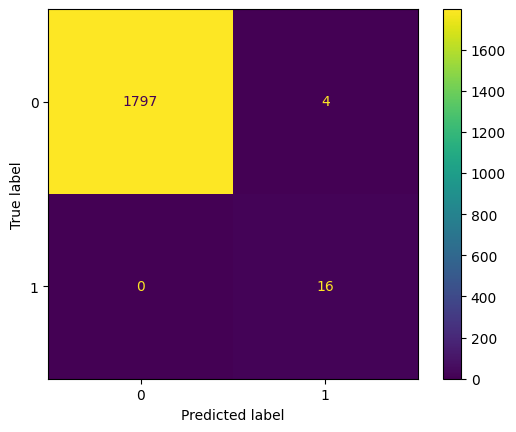

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logistic)
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [45]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9972482113373693
Precision: 1.0
Recall   : 0.6875
F1 Score : 0.8148148148148148
ROC AUC  : 0.998924208772904

Confusion Matrix:
[[1801    0]
 [   5   11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      0.69      0.81        16

    accuracy                           1.00      1817
   macro avg       1.00      0.84      0.91      1817
weighted avg       1.00      1.00      1.00      1817



In [47]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

     Feature  Importance
3696   F3912    0.068538
1967   F2029    0.016173
3602   F3811    0.015797
3596   F3805    0.013024
1859   F1921    0.012464
1319   F1381    0.011416
1643   F1705    0.011251
1103   F1165    0.011151
3604   F3813    0.011078
1752   F1814    0.010769
1535   F1597    0.009786
2075   F2137    0.009133
2401   F2489    0.008498
887     F949    0.008472
3591   F3800    0.008289
3598   F3807    0.008276
1439   F1501    0.007810
241     F270    0.007673
1428   F1490    0.007644
3590   F3799    0.007520


In [48]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

y_pred_th0_30 = (y_prob >= 0.30).astype(int)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_th0_30))
print("Precision:", precision_score(y_test, y_pred_th0_30))
print("Recall   :", recall_score(y_test, y_pred_th0_30))
print("F1 Score :", f1_score(y_test, y_pred_th0_30))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_th0_30))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_th0_30))

Accuracy : 0.9950467804072647
Precision: 0.7058823529411765
Recall   : 0.75
F1 Score : 0.7272727272727273
ROC AUC  : 0.998924208772904

Confusion Matrix:
[[1796    5]
 [   4   12]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       0.71      0.75      0.73        16

    accuracy                           1.00      1817
   macro avg       0.85      0.87      0.86      1817
weighted avg       1.00      1.00      1.00      1817



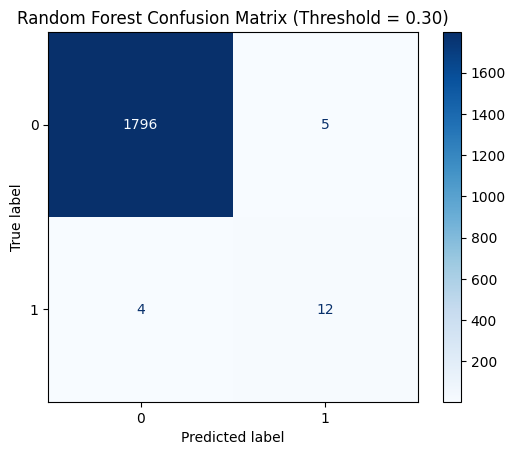

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_th0_30,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix (Threshold = 0.30)")
plt.show()

In [51]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)


110.76923076923077


In [52]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [53]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Confusion Matrix:
[[1801    0]
 [   0   16]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      1.00      1.00        16

    accuracy                           1.00      1817
   macro avg       1.00      1.00      1.00      1817
weighted avg       1.00      1.00      1.00      1817



F3912    0.716049
F1057    0.084206
F3799    0.071225
F1165    0.034098
F1813    0.022489
F1814    0.009025
F3104    0.006878
F162     0.003158
F1922    0.002857
F3105    0.002796
F2686    0.002466
F364     0.002048
F358     0.001983
F3805    0.001691
F3914    0.001584
F2030    0.001524
F13      0.001425
F1961    0.001395
F202     0.001386
F114     0.001362
dtype: float32


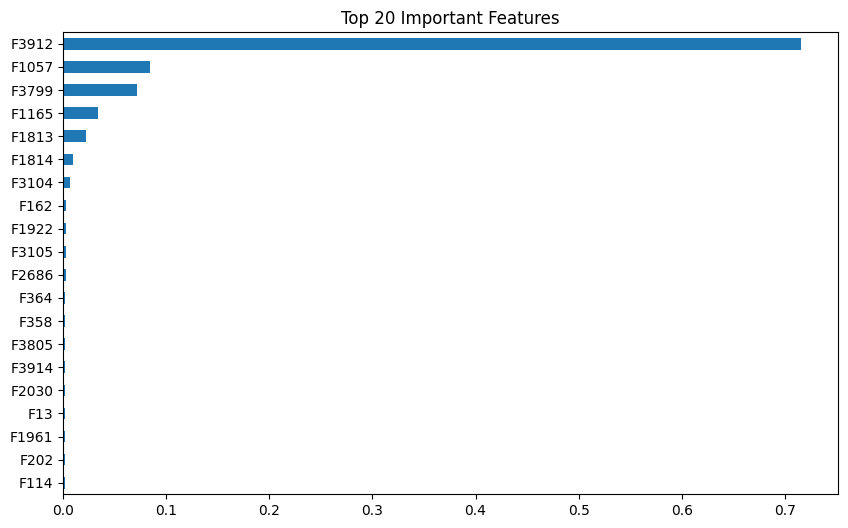

In [55]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)
print(importance.head(20))
plt.figure(figsize=(10,6))
importance.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

In [56]:
df["F3912"].value_counts().head()


F3912
0.0    9000
1.0      82
Name: count, dtype: int64

In [57]:
pd.crosstab(df["F3912"], df["F3924"])

F3924,0,1
F3912,,
0.0,8998,2
1.0,3,79


In [58]:
pd.crosstab(df["F1057"], df["F3924"])


F3924,0,1
F1057,,
0.000000e+00,68,0
1.000000e+00,1,0
5.000000e+00,1,0
1.000000e+01,1,0
1.974000e+01,1,0
...,...,...
4.300000e+09,1,0
4.400000e+09,1,0
5.272869e+09,1,0


In [59]:
pd.crosstab(df["F3799"], df["F3924"])

F3924,0,1
F3799,,
5.900000e+01,1,0
1.100000e+02,1,0
2.000000e+03,1,0
2.760000e+03,1,0
3.785500e+03,1,0
...,...,...
3.615659e+10,1,0
3.946851e+10,1,0
4.246379e+10,1,0


In [60]:
X_drp = X_drp.drop(columns=["F3912"])

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_drp,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [62]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


F3914    0.103393
F3898    0.077532
F3907    0.030314
F3920    0.029004
F3921    0.028058
F2527    0.026413
F949     0.026333
F1639    0.025813
F1597    0.025319
F1968    0.024855
F3824    0.022918
F3534    0.022679
F1921    0.021403
F3799    0.018365
F3811    0.017773
F164     0.017109
F1707    0.016540
F2236    0.014667
F3800    0.014085
F3495    0.013677
dtype: float32


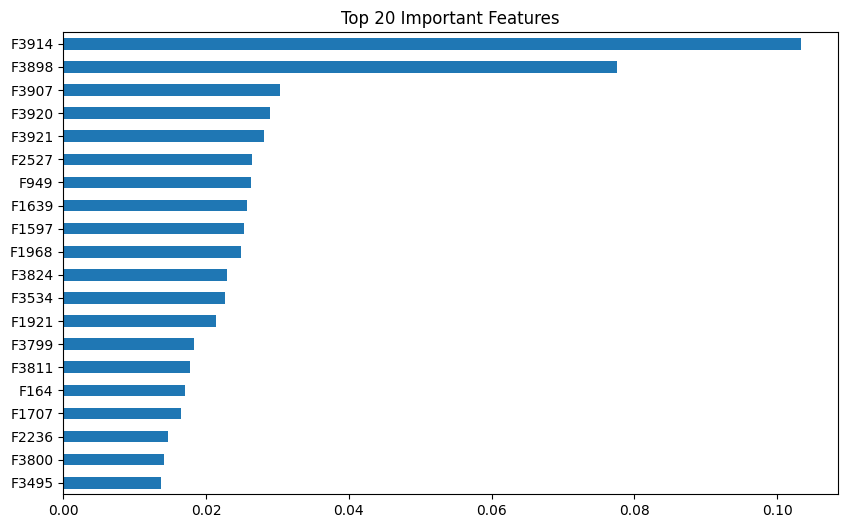

In [63]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)
print(importance.head(20))
plt.figure(figsize=(10,6))
importance.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Confusion Matrix:
[[1801    0]
 [   0   16]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      1.00      1.00        16

    accuracy                           1.00      1817
   macro avg       1.00      1.00      1.00      1817
weighted avg       1.00      1.00      1.00      1817



In [65]:
top_features = ["F3914", "F3898", "F3907", "F3920", "F3921"]

for col in top_features:
    print(f"\n===== {col} =====")
    print(pd.crosstab(df[col], df["F3924"]))


===== F3914 =====
F3924     0   1
F3914          
0.0    6108  77
1.0    2893   4

===== F3898 =====
F3924     0   1
F3898          
0.0    2772  39
1.0    1115  36
2.0     236   4
3.0    4753   2
4.0      86   0
5.0      24   0
6.0       7   0
57.0      8   0

===== F3907 =====
F3924     0   1
F3907          
0.0    8533  81
1.0     468   0

===== F3920 =====
F3924     0   1
F3920          
0.0    7477  63
1.0    1323   9
2.0     123   4
3.0      43   3
4.0      17   2
5.0       8   0
6.0       6   0
7.0       1   0
8.0       2   0
14.0      1   0

===== F3921 =====
F3924     0   1
F3921          
0.0    6448  53
1.0    2267  23
2.0     201   3
3.0      45   1
4.0      14   0
5.0      10   0
6.0       8   0
7.0       6   0
8.0       0   1
9.0       1   0
11.0      1   0


In [66]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(7265, 3745)
(1817, 3745)
F3924
0    7200
1      65
Name: count, dtype: int64
F3924
0    1801
1      16
Name: count, dtype: int64


In [67]:
import pandas as pd

train_df = X_train.copy()
train_df["target"] = y_train.values

test_df = X_test.copy()
test_df["target"] = y_test.values

train_hash = pd.util.hash_pandas_object(train_df, index=False)
test_hash = pd.util.hash_pandas_object(test_df, index=False)

duplicates = train_hash.isin(test_hash)

print("Duplicate rows:", duplicates.sum())

Duplicate rows: 0


In [68]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X_drp,          # data after removing F2230 and F3912
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)
print(xgb_model)
print(scores)
print("Mean F1:", scores.mean())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)
[0.8        0.9375     0.8        0.86666667 0.81481481]
Mean F1: 0.8437962962962964


In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X_drp,   # Full dataset after dropping F2230 and F3912
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)
print(logistic_model)
print(scores)
print("Mean F1:", scores.mean())

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
[0.46511628 0.48148148 0.41935484 0.53846154 0.30434783]
Mean F1: 0.4417523927618842


In [70]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf_model,
    X_drp,          # data after removing F2230 and F3912
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)
print(rf_model)
print(scores)
print("Mean F1:", scores.mean())

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
[0.38095238 0.64       0.81481481 0.75862069 0.54545455]
Mean F1: 0.6279684861753828


In [71]:
import joblib

joblib.dump(xgb_model, "xgboost_model.pkl")

['xgboost_model.pkl']

In [74]:
feature_columns = X_drp.columns.tolist()
feature_columns


['F1',
 'F2',
 'F3',
 'F4',
 'F5',
 'F6',
 'F7',
 'F8',
 'F9',
 'F10',
 'F11',
 'F12',
 'F13',
 'F14',
 'F15',
 'F16',
 'F17',
 'F18',
 'F19',
 'F20',
 'F21',
 'F22',
 'F23',
 'F24',
 'F25',
 'F26',
 'F27',
 'F28',
 'F29',
 'F30',
 'F31',
 'F32',
 'F33',
 'F34',
 'F35',
 'F37',
 'F38',
 'F40',
 'F41',
 'F43',
 'F44',
 'F46',
 'F47',
 'F49',
 'F50',
 'F52',
 'F53',
 'F54',
 'F55',
 'F56',
 'F57',
 'F58',
 'F59',
 'F60',
 'F61',
 'F62',
 'F63',
 'F64',
 'F65',
 'F66',
 'F67',
 'F68',
 'F69',
 'F70',
 'F71',
 'F72',
 'F73',
 'F74',
 'F75',
 'F76',
 'F77',
 'F78',
 'F79',
 'F80',
 'F81',
 'F82',
 'F83',
 'F84',
 'F85',
 'F86',
 'F87',
 'F88',
 'F89',
 'F90',
 'F91',
 'F92',
 'F93',
 'F94',
 'F95',
 'F96',
 'F97',
 'F98',
 'F99',
 'F100',
 'F101',
 'F102',
 'F103',
 'F104',
 'F105',
 'F106',
 'F107',
 'F108',
 'F109',
 'F110',
 'F111',
 'F112',
 'F113',
 'F114',
 'F115',
 'F116',
 'F117',
 'F118',
 'F119',
 'F120',
 'F121',
 'F122',
 'F123',
 'F124',
 'F125',
 'F126',
 'F127',
 'F129',
 'F1

In [75]:
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']